---
tags: [tutorial]
---

# Controlling Gates and Sub-Kernels with `qmc.control`

*(intro paragraph — to be written)*

In [1]:
# Install the latest Qamomile from pip.
# !pip install qamomile

In [2]:
import math

import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## 1. The minimal example: controlled-RX

The smallest useful application of `qmc.control` is wrapping a
single built-in rotation. `qmc.rx(q, angle)` is a one-qubit
gate; passing it to `qmc.control` produces a two-qubit
controlled-RX.

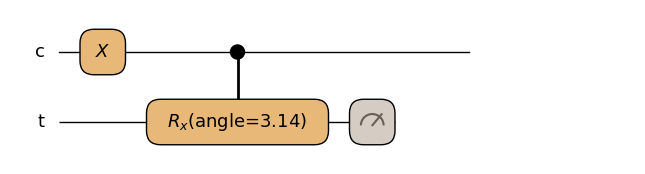

In [3]:
@qmc.qkernel
def crx_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # Drive the control to |1> so the controlled rotation fires.
    c = qmc.x(c)
    crx = qmc.control(qmc.rx)
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_demo.draw()

Three things to notice at the call site:

- `qmc.control(qmc.rx)` is evaluated at *decoration time*. The
  returned `ControlledGate` (here bound to `crx`) is a reusable
  value; you can stash it in a variable and call it multiple
  times.
- When you call `crx(c, t, angle=...)`, the control qubits come
  first as positional arguments, then the targets, then any
  classical keyword arguments. The order mirrors the wrapped
  `qmc.rx(q, angle)` signature with one extra control prefixed.
- The keyword name for the classical parameter is whatever the
  wrapped function uses (`angle` for `qmc.rx`, `theta` for
  `qmc.p`, etc.) — `qmc.control` does not rename it.

## 2. Two modes at a glance

`qmc.control` has two modes. Which one you are in is decided
entirely by the type you pass for `num_controls`: a Python
`int` puts you in *concrete* mode, a `qmc.UInt` handle (or any
`UInt` expression like `n - 1`) puts you in *symbolic* mode.
Everything else about the call follows from that choice.

| Aspect | Concrete | Symbolic |
| --- | --- | --- |
| `num_controls=` | Python `int` (default `1`) | `qmc.UInt` handle, or any `UInt` expression |
| Control argument(s) | one or more positional args (`Qubit`, `VectorView`, or `Vector[Qubit]`) whose qubit counts sum to `num_controls` | exactly one `Vector[Qubit]` or `VectorView` *pool* |
| `controlled_indices=` | not accepted | optional — picks which slots of the pool are active |
| Control count resolved at | decoration time | transpile time (from `bindings`) |

A short decision rule: reach for *concrete* mode when the
control count is a literal you know while writing the qkernel
and you want to name each control qubit individually. Reach for
*symbolic* mode when the count is a kernel parameter (or an
expression over one — `num_controls=n - 1` is the textbook
multi-controlled form).

Most of `qmc.control`'s features (`power=`, default values,
classical-kwarg reordering, sub-kernels that take
`Vector[Qubit]`, ...) behave identically in both modes; Section
3 collects those. The handful of features that are mode-specific
are split between Section 4 (concrete only) and Section 5
(symbolic only).

## 3. Patterns that work in BOTH modes

Everything in this section is mode-agnostic. Each subsection
shows the feature in concrete mode (because the code is shorter
without a `UInt` kernel parameter in the picture), but the same
call site works in symbolic mode if you replace
`num_controls=<int>` with `num_controls=<UInt expression>`.

### 3.1 Wrapping any callable

`qmc.control` accepts either a built-in gate function (`qmc.rx`,
`qmc.h`, `qmc.p`, ...) or any user-defined `@qmc.qkernel`. The
wrapper does not care which: it looks at the wrapped callable's
signature, extracts the quantum operands and the classical
parameters, and emits a controlled-U around the rest. In the
example below, `ch` wraps a single primitive and `cg` wraps a
user-defined kernel body with two gates inside.

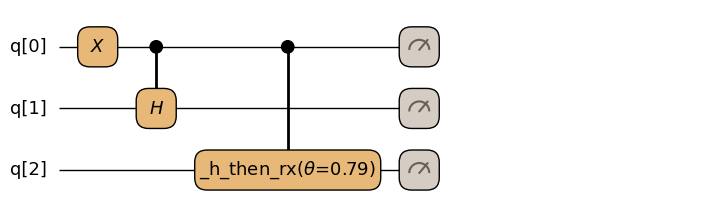

In [4]:
@qmc.qkernel
def _h_then_rx(q: qmc.Qubit, theta: qmc.Float) -> qmc.Qubit:
    q = qmc.h(q)
    q = qmc.rx(q, theta)
    return q


@qmc.qkernel
def wrap_any_callable_demo() -> qmc.Vector[qmc.Bit]:
    # q[0] is the shared control; q[1] / q[2] are the two targets.
    q = qmc.qubit_array(3, "q")
    q[0] = qmc.x(q[0])
    ch = qmc.control(qmc.h)  # built-in gate function
    q[0], q[1] = ch(q[0], q[1])
    cg = qmc.control(_h_then_rx)  # user @qmc.qkernel
    q[0], q[2] = cg(q[0], q[2], theta=math.pi / 4)
    return qmc.measure(q)


wrap_any_callable_demo.draw()

### 3.2 Sub-kernel taking `Vector[Qubit]`

A wrapped kernel may take a `Vector[Qubit]` argument. The caller
passes a `Vector` or a `VectorView` of the matching length, and
the controlled-U emit pass expands the body per-element so each
inner gate becomes a controlled gate on the right physical
qubit. This is how you control a register-wide operation without
spelling out one operand per qubit at the call site.

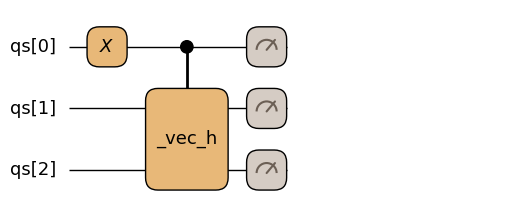

In [5]:
@qmc.qkernel
def _vec_h(qs: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    qs[0] = qmc.h(qs[0])
    qs[1] = qmc.h(qs[1])
    return qs


@qmc.qkernel
def vec_target_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(3, "qs")
    qs[0] = qmc.x(qs[0])
    cg = qmc.control(_vec_h, num_controls=1)
    qs[0], qs[1:3] = cg(qs[0], qs[1:3])
    return qmc.measure(qs)


vec_target_demo.draw()

### 3.3 Default values from the wrapped kernel's signature

When the wrapped `@qmc.qkernel` declares a Python default for a
classical parameter, callers may omit that keyword. The wrapper
fills the missing value in via `inspect.Signature.bind +
apply_defaults`, so the default reaches the controlled-U just
like a normal direct call. (Only `@qmc.qkernel`-wrapped
callables can carry defaults — see Section 6.9 for what happens
if you try to do the same with a plain Python function.)

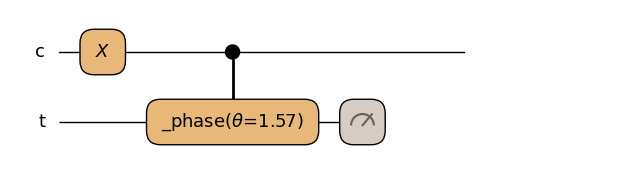

In [6]:
@qmc.qkernel
def _phase(q: qmc.Qubit, theta: qmc.Float = math.pi / 2) -> qmc.Qubit:
    return qmc.rx(q, theta)


@qmc.qkernel
def default_arg_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_phase)
    c, t = cg(c, t)  # theta defaults to math.pi / 2
    return qmc.measure(t)


default_arg_demo.draw()

### 3.4 Classical keyword arguments in any order

Classical kwargs at the call site are matched by name and
reordered to follow the wrapped kernel's declared signature,
so the same call compiled with the kwargs in either order
produces the same circuit. The assertion at the end of the cell
verifies that explicitly by comparing the transpiled Qiskit
circuits character-for-character.

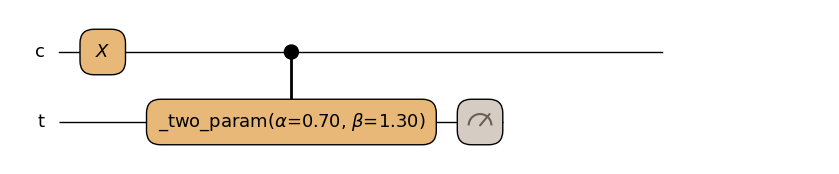

In [7]:
@qmc.qkernel
def _two_param(q: qmc.Qubit, alpha: qmc.Float, beta: qmc.Float) -> qmc.Qubit:
    q = qmc.rx(q, alpha)
    q = qmc.rz(q, beta)
    return q


@qmc.qkernel
def kwargs_in_order() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_two_param)
    c, t = cg(c, t, alpha=0.7, beta=1.3)
    return qmc.measure(t)


@qmc.qkernel
def kwargs_reversed() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_two_param)
    c, t = cg(c, t, beta=1.3, alpha=0.7)
    return qmc.measure(t)


exe_a = transpiler.transpile(kwargs_in_order)
exe_b = transpiler.transpile(kwargs_reversed)
assert str(exe_a.compiled_quantum[0].circuit) == str(exe_b.compiled_quantum[0].circuit)

kwargs_in_order.draw()

### 3.5 Controlling `U^k` with `power=`

Passing `power=k` controls the *k-th power* of the wrapped
unitary instead of `U` itself — the standard pattern in QPE,
where the j-th register applies a controlled-`U^(2**j)`.
`power` accepts a Python `int` (resolved at compile time) **or**
a `qmc.UInt` handle (resolved at transpile time from
`bindings`), and this works regardless of whether `num_controls`
is concrete or symbolic. Both shapes are shown side by side.

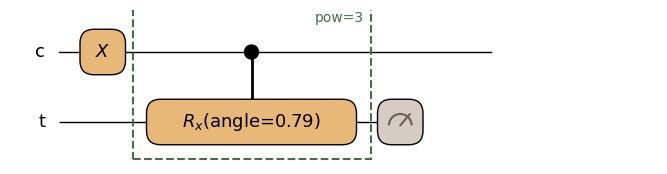

In [8]:
@qmc.qkernel
def power_demo_concrete() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(qmc.rx)  # num_controls = 1 (concrete)
    c, t = cg(c, t, angle=math.pi / 4, power=3)  # power is a Python int
    return qmc.measure(t)


@qmc.qkernel
def power_demo_symbolic(k: qmc.UInt) -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(qmc.rx)
    c, t = cg(c, t, angle=math.pi / 4, power=k)  # power is a UInt handle
    return qmc.measure(t)


power_demo_concrete.draw()

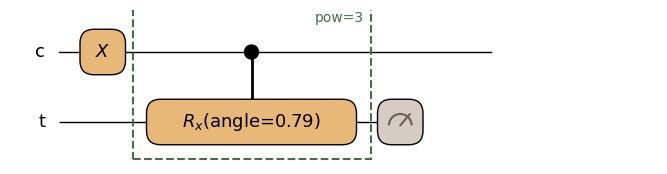

In [9]:
# Symbolic-power example needs a binding for `k` before draw / transpile.
power_demo_symbolic.draw(k=3)

## 4. Concrete-mode-only patterns

*(to be written)*

### 4.1 Multiple separate positional control args (CCX style)

*(to be written)*

### 4.2 Mixing scalar Qubit and `VectorView` controls

*(to be written)*

## 5. Symbolic-mode-only patterns

*(to be written)*

### 5.1 `num_controls = n` over a whole pool

*(to be written)*

### 5.2 Canonical `n - 1` multi-controlled form

*(to be written)*

### 5.3 Selecting a subset with `controlled_indices=`

*(to be written)*

### 5.4 `controlled_indices` with `UInt` entries

*(to be written)*

## 6. Patterns that don't work

*(to be written — uses an `expect_error` helper so each rejected
shape doubles as a regression check)*

## 7. Summary

*(to be written)*